In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_csv(
    "final_merged_dataset.csv"
)

merged.head()

,demand,occupancy,price,hour,day,month,is_weekend,demand_occ_ratio,prev_price
0,38.514720,24.356275,0.911018,0,19,6,1,1.581306,0.911018
1,40.093327,24.643725,0.911018,0,19,6,1,1.626918,0.911018
2,44.544098,24.923077,0.911018,0,19,6,1,1.787263,0.911018
3,46.450680,25.072874,0.911018,0,19,6,1,1.852627,0.911018
4,47.883763,25.238866,0.911018,0,19,6,1,1.897223,0.911018


In [17]:
merged["old_revenue"] = (
    merged["price"]
    *
    merged["demand"]
)

In [25]:
high_occ = merged["occupancy"].quantile(0.80)
medium_occ = merged["occupancy"].quantile(0.60)
low_occ = merged["occupancy"].quantile(0.20)

print("High:", high_occ)
print("Medium:", medium_occ)
print("Low:", low_occ)

High: 25.85182186234818
Medium: 23.364372469635622
Low: 18.26315789473684


In [26]:
def recommend_price(
    occupancy,
    current_price
):

    if occupancy >= high_occ:
        return current_price * 1.15

    elif occupancy >= medium_occ:
        return current_price * 1.10

    elif occupancy <= low_occ:
        return current_price * 0.85

    return current_price

In [19]:
merged["recommended_price"] = merged.apply(
    lambda row:
    recommend_price(
        row["occupancy"],
        row["price"]
    ),
    axis=1
)

In [20]:
merged["new_revenue"] = (
    merged["recommended_price"]
    *
    merged["demand"]
)

In [21]:
old_rev = merged["old_revenue"].sum()

new_rev = merged["new_revenue"].sum()

gain = (
    (new_rev - old_rev)
    /
    old_rev
) * 100

print(
    f"Revenue Gain: {gain:.2f}%"
)

Revenue Gain: 3.06%


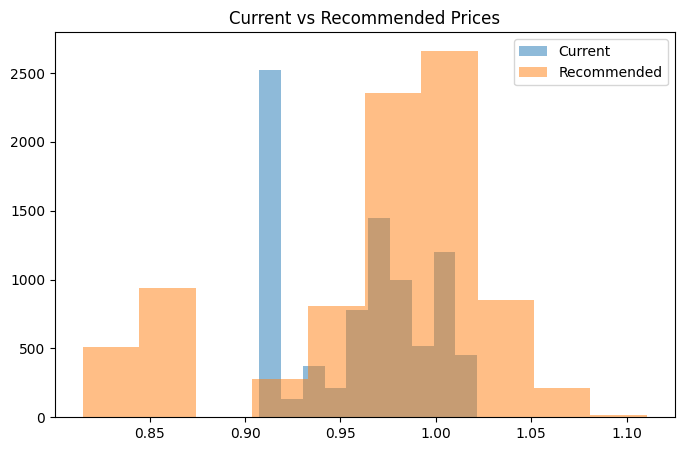

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    merged["price"],
    alpha=0.5,
    label="Current"
)

plt.hist(
    merged["recommended_price"],
    alpha=0.5,
    label="Recommended"
)

plt.legend()

plt.title(
    "Current vs Recommended Prices"
)

plt.show()

In [23]:
def utilization_zone(x):

    if x >= 27:
        return "High"

    elif x <= 18:
        return "Low"

    return "Medium"

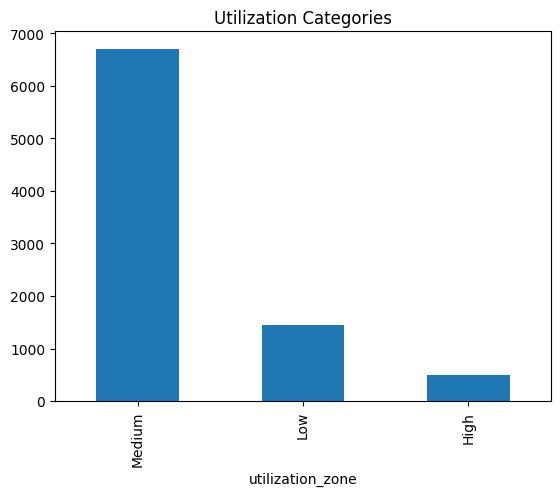

In [27]:
merged[
    "utilization_zone"
] = merged[
    "occupancy"
].apply(
    utilization_zone
)

merged[
    "utilization_zone"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Utilization Categories"
)

plt.show()